<a href="https://colab.research.google.com/github/dzidz1/Freeuni_ML_Walmart_Sales_Forecasting/blob/main/model_experiment_PatchTST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install

In [ ]:
!pip -q install -U kaggle neuralforecast mlflow dagshub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.5/111.5 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.0/302.0 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 122.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 130.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 91.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.6/348.6 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 131.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Imports + Config

In [ ]:
import os
import random
import warnings
from pathlib import Path

import mlflow
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from google.colab import drive, userdata
from neuralforecast import NeuralForecast
from neuralforecast.models import PatchTST

warnings.filterwarnings("ignore")

SEED = 42
QUICK_RUN = False
VALIDATION_WEEKS = 13
FREQ = "W-FRI"
MODEL_NAME = "PatchTST"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


# Paths + Load Data

In [ ]:
drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/walmart_final_project")
DATA_DIR = PROJECT_DIR / "data"
ARTIFACT_DIR = PROJECT_DIR / "artifacts" / MODEL_NAME.lower()

DATA_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

kaggle_username = userdata.get("KAGGLE_USERNAME")
kaggle_token = userdata.get("KAGGLE_API_TOKEN")

os.environ["KAGGLE_USERNAME"] = kaggle_username
os.environ["KAGGLE_KEY"] = kaggle_token

competition_name = "walmart-recruiting-store-sales-forecasting"
zip_path = DATA_DIR / f"{competition_name}.zip"

if not zip_path.exists():
    !kaggle competitions download -c {competition_name} -p {DATA_DIR}
else:
    print("Competition zip already exists:", zip_path)

!unzip -o {zip_path} -d {DATA_DIR}

train = pd.read_csv(DATA_DIR / "train.csv.zip")
test = pd.read_csv(DATA_DIR / "test.csv.zip")
features = pd.read_csv(DATA_DIR / "features.csv.zip")
stores = pd.read_csv(DATA_DIR / "stores.csv")
sample_submission = pd.read_csv(DATA_DIR / "sampleSubmission.csv.zip")

for df in [train, test, features]:
    df["Date"] = pd.to_datetime(df["Date"])

print("train:", train.shape)
print("test:", test.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Competition zip already exists: /content/drive/MyDrive/walmart_final_project/data/walmart-recruiting-store-sales-forecasting.zip
Archive:  /content/drive/MyDrive/walmart_final_project/data/walmart-recruiting-store-sales-forecasting.zip
  inflating: /content/drive/MyDrive/walmart_final_project/data/features.csv.zip  
  inflating: /content/drive/MyDrive/walmart_final_project/data/sampleSubmission.csv.zip  
  inflating: /content/drive/MyDrive/walmart_final_project/data/stores.csv  
  inflating: /content/drive/MyDrive/walmart_final_project/data/test.csv.zip  
  inflating: /content/drive/MyDrive/walmart_final_project/data/train.csv.zip  
train: (421570, 5)
test: (115064, 4)


# Metric + Preprocessing

In [ ]:
def make_unique_id(df):
    return df["Store"].astype(str) + "_" + df["Dept"].astype(str)


def walmart_wmae(y_true, y_pred, is_holiday):
    weights = np.where(pd.Series(is_holiday).astype(bool).to_numpy(), 5, 1)
    errors = np.abs(np.asarray(y_true) - np.asarray(y_pred))
    return float(np.sum(weights * errors) / np.sum(weights))


def build_calendar(train_df, test_df):
    calendar = pd.concat(
        [train_df[["Date", "IsHoliday"]], test_df[["Date", "IsHoliday"]]],
        ignore_index=True,
    )

    return (
        calendar
        .drop_duplicates("Date")
        .rename(columns={"Date": "ds"})
        .sort_values("ds")
        .reset_index(drop=True)
    )


def prepare_patchtst_frame(raw_train, calendar):
    base = raw_train.copy()
    base["unique_id"] = make_unique_id(base)
    base = base.rename(columns={"Date": "ds", "Weekly_Sales": "y"})
    base = base[["unique_id", "ds", "y"]]

    all_ids = base["unique_id"].drop_duplicates().sort_values()
    all_dates = pd.date_range(base["ds"].min(), base["ds"].max(), freq=FREQ)

    full_grid = (
        pd.MultiIndex
        .from_product([all_ids, all_dates], names=["unique_id", "ds"])
        .to_frame(index=False)
    )

    out = full_grid.merge(base, on=["unique_id", "ds"], how="left")
    out["y"] = out["y"].fillna(0.0)

    out = out.merge(calendar, on="ds", how="left")
    out["IsHoliday"] = out["IsHoliday"].fillna(False).astype(bool)

    return out.sort_values(["unique_id", "ds"]).reset_index(drop=True)

# Build Dataset

In [ ]:
calendar = build_calendar(train, test)
nf_full = prepare_patchtst_frame(train, calendar)

if QUICK_RUN:
    top_ids = (
        train.assign(unique_id=make_unique_id(train))
        .groupby("unique_id")["Weekly_Sales"]
        .sum()
        .nlargest(120)
        .index
    )

    nf_full = nf_full[nf_full["unique_id"].isin(top_ids)].copy()

print("series:", nf_full["unique_id"].nunique())
print("rows:", len(nf_full))
print("date range:", nf_full["ds"].min().date(), "to", nf_full["ds"].max().date())

nf_full.head()

series: 3331
rows: 476333
date range: 2010-02-05 to 2012-10-26


,unique_id,ds,y,IsHoliday
0,10_1,2010-02-05,40212.84,False
1,10_1,2010-02-12,67699.32,True
2,10_1,2010-02-19,49748.33,False
3,10_1,2010-02-26,33601.22,False
4,10_1,2010-03-05,36572.44,False


# MLflow + DagsHub

In [ ]:
DAGSHUB_USERNAME = "mgior23"
DAGSHUB_REPO_OWNER = "adzid23"
DAGSHUB_REPO_NAME = "Freeuni_ML_Walmart_Sales_Forecasting"

dagshub_token = userdata.get("DAGSHUB_TOKEN")

os.environ["MLFLOW_TRACKING_USERNAME"] = DAGSHUB_USERNAME
os.environ["MLFLOW_TRACKING_PASSWORD"] = dagshub_token

mlflow.set_tracking_uri(
    f"https://dagshub.com/{DAGSHUB_REPO_OWNER}/{DAGSHUB_REPO_NAME}.mlflow"
)

if mlflow.active_run():
    mlflow.end_run()

mlflow.set_experiment("PatchTST_Training")

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("Experiment: PatchTST_Training")

MLflow tracking URI: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow
Experiment: PatchTST_Training


# Log Setup + Split

In [ ]:
with mlflow.start_run(run_name="PatchTST_Preprocessing"):
    mlflow.log_params({
        "model_family": "Deep Learning",
        "architecture": "PatchTST",
        "frequency": FREQ,
        "missing_week_strategy": "fill_missing_sales_with_zero",
        "quick_run": QUICK_RUN,
        "validation_weeks": VALIDATION_WEEKS,
    })

    mlflow.log_metrics({
        "n_series": nf_full["unique_id"].nunique(),
        "n_rows": len(nf_full),
        "n_dates": nf_full["ds"].nunique(),
    })

with mlflow.start_run(run_name="PatchTST_Feature_Setup"):
    mlflow.log_params({
        "forecasting_type": "global_univariate_patch_transformer",
        "target": "Weekly_Sales",
        "external_features_used": False,
        "holiday_used_for_metric_only": True,
    })

last_train_date = nf_full["ds"].max()
valid_start = last_train_date - pd.Timedelta(weeks=VALIDATION_WEEKS - 1)

train_part = nf_full[nf_full["ds"] < valid_start][["unique_id", "ds", "y"]].copy()
valid_part = nf_full[nf_full["ds"] >= valid_start].copy()

print("train_part:", train_part.shape)
print("valid_part:", valid_part.shape)
print("validation start:", valid_start.date())

🏃 View run PatchTST_Preprocessing at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/4/runs/9155bde4b9854306b084726436fe4552
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/4
🏃 View run PatchTST_Feature_Setup at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/4/runs/7a930f74192b45e0a02847bdeddd45a7
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/4
train_part: (433030, 3)
valid_part: (43303, 4)
validation start: 2012-08-03


# Baseline PatchTST

In [ ]:
run_suffix = "Quick" if QUICK_RUN else "Full"

BASELINE_INPUT_SIZE = 78
BASELINE_STEPS = 50 if QUICK_RUN else 1000

baseline_model = PatchTST(
    h=VALIDATION_WEEKS,
    input_size=BASELINE_INPUT_SIZE,
    patch_len=13,
    stride=13,
    hidden_size=64,
    n_heads=4,
    max_steps=BASELINE_STEPS,
    scaler_type="standard",
    learning_rate=1e-4,
    random_seed=SEED,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    enable_progress_bar=True,
)

baseline_engine = NeuralForecast(models=[baseline_model], freq=FREQ)

with mlflow.start_run(run_name=f"PatchTST_Training_Baseline_{run_suffix}") as run:
    mlflow.log_params({
        "architecture": "PatchTST",
        "run_type": "baseline",
        "quick_run": QUICK_RUN,
        "validation_weeks": VALIDATION_WEEKS,
        "input_size": BASELINE_INPUT_SIZE,
        "patch_len": 13,
        "stride": 13,
        "hidden_size": 64,
        "n_heads": 4,
        "max_steps": BASELINE_STEPS,
        "scaler_type": "standard",
        "learning_rate": 1e-4,
        "frequency": FREQ,
        "n_series": train_part["unique_id"].nunique(),
    })

    baseline_engine.fit(df=train_part)
    baseline_pred = baseline_engine.predict()

    baseline_scored = valid_part.merge(baseline_pred, on=["unique_id", "ds"], how="inner")
    baseline_scored["PatchTST"] = baseline_scored["PatchTST"].clip(lower=0)

    baseline_wmae = walmart_wmae(
        baseline_scored["y"],
        baseline_scored["PatchTST"],
        baseline_scored["IsHoliday"],
    )

    mlflow.log_metric("validation_wmae", baseline_wmae)

    baseline_path = ARTIFACT_DIR / "baseline_model"
    baseline_engine.save(path=str(baseline_path), model_index=None, overwrite=True, save_dataset=False)
    mlflow.log_artifacts(str(baseline_path), artifact_path="model")

    baseline_scored_path = ARTIFACT_DIR / "baseline_validation_predictions.csv"
    baseline_scored.to_csv(baseline_scored_path, index=False)
    mlflow.log_artifact(str(baseline_scored_path), artifact_path="validation")

    patchtst_baseline_run_id = run.info.run_id

print("PatchTST baseline WMAE:", round(baseline_wmae, 4))
baseline_scored.head()

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type              | Params | Mode 
------------------------------------------------------------------
0 | loss                | MAE               | 0      | train
1 | hist_cat_embeddings | ModuleList        | 0      | train
2 | futr_cat_embeddings | ModuleList        | 0      | train
3 | stat_cat_embeddings | ModuleList        | 0      | train
4 | padder_train        | ConstantPad1d     | 0      | train
5 | scaler              | TemporalNorm      | 0      | train
6 | model               | PatchTST_backbone | 157 K  | train
------------------------------------------------------------------
157 K     Trainable params
3 

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

🏃 View run PatchTST_Training_Baseline_Full at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/4/runs/48dab57d9d51431c8b5b7fa3d3ce7e9d
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/4
PatchTST baseline WMAE: 1165.825


,unique_id,ds,y,IsHoliday,PatchTST
0,10_1,2012-08-03,26390.26,False,28269.320312
1,10_1,2012-08-10,26320.29,False,26948.162109
2,10_1,2012-08-17,26752.40,False,27247.236328
3,10_1,2012-08-24,26804.84,False,26101.111328
4,10_1,2012-08-31,26083.28,False,26684.625000


# Tuning PatchTST

In [ ]:
TUNED_INPUT_SIZE = 104
TUNED_STEPS = 75 if QUICK_RUN else 1500

tuned_model = PatchTST(
    h=VALIDATION_WEEKS,
    input_size=TUNED_INPUT_SIZE,
    patch_len=16,
    stride=8,
    hidden_size=128,
    n_heads=8,
    max_steps=TUNED_STEPS,
    scaler_type="standard",
    learning_rate=5e-5,
    random_seed=SEED,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    enable_progress_bar=True,
)

tuned_engine = NeuralForecast(models=[tuned_model], freq=FREQ)

with mlflow.start_run(run_name=f"PatchTST_Tuning_Input104_Patch16_Stride8_{run_suffix}") as run:
    mlflow.log_params({
        "architecture": "PatchTST",
        "run_type": "hyperparameter_tuning",
        "quick_run": QUICK_RUN,
        "validation_weeks": VALIDATION_WEEKS,
        "input_size": TUNED_INPUT_SIZE,
        "patch_len": 16,
        "stride": 8,
        "hidden_size": 128,
        "n_heads": 8,
        "max_steps": TUNED_STEPS,
        "scaler_type": "standard",
        "learning_rate": 5e-5,
        "frequency": FREQ,
        "n_series": train_part["unique_id"].nunique(),
    })

    tuned_engine.fit(df=train_part)
    tuned_pred = tuned_engine.predict()

    tuned_scored = valid_part.merge(tuned_pred, on=["unique_id", "ds"], how="inner")
    tuned_scored["PatchTST"] = tuned_scored["PatchTST"].clip(lower=0)

    tuned_wmae = walmart_wmae(
        tuned_scored["y"],
        tuned_scored["PatchTST"],
        tuned_scored["IsHoliday"],
    )

    mlflow.log_metric("validation_wmae", tuned_wmae)

    tuned_path = ARTIFACT_DIR / "input104_patch16_stride8_model"
    tuned_engine.save(path=str(tuned_path), model_index=None, overwrite=True, save_dataset=False)
    mlflow.log_artifacts(str(tuned_path), artifact_path="model")

    tuned_scored_path = ARTIFACT_DIR / "input104_patch16_stride8_validation_predictions.csv"
    tuned_scored.to_csv(tuned_scored_path, index=False)
    mlflow.log_artifact(str(tuned_scored_path), artifact_path="validation")

    patchtst_tuning_run_id = run.info.run_id

print("PatchTST tuned WMAE:", round(tuned_wmae, 4))
tuned_scored.head()

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type              | Params | Mode 
------------------------------------------------------------------
0 | loss                | MAE               | 0      | train
1 | hist_cat_embeddings | ModuleList        | 0      | train
2 | futr_cat_embeddings | ModuleList        | 0      | train
3 | stat_cat_embeddings | ModuleList        | 0      | train
4 | padder_train        | ConstantPad1d     | 0      | train
5 | scaler              | TemporalNorm      | 0      | train
6 | model               | PatchTST_backbone | 422 K  | train
------------------------------------------------------------------
422 K     Trainable params
3 

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1500` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

🏃 View run PatchTST_Tuning_Input104_Patch16_Stride8_Full at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/4/runs/51bc74253d054a94ae9f55bb5e35073f
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/4
PatchTST tuned WMAE: 1259.7746


,unique_id,ds,y,IsHoliday,PatchTST
0,10_1,2012-08-03,26390.26,False,29659.630859
1,10_1,2012-08-10,26320.29,False,28098.191406
2,10_1,2012-08-17,26752.40,False,27359.458984
3,10_1,2012-08-24,26804.84,False,26996.230469
4,10_1,2012-08-31,26083.28,False,26500.617188


# Visualization

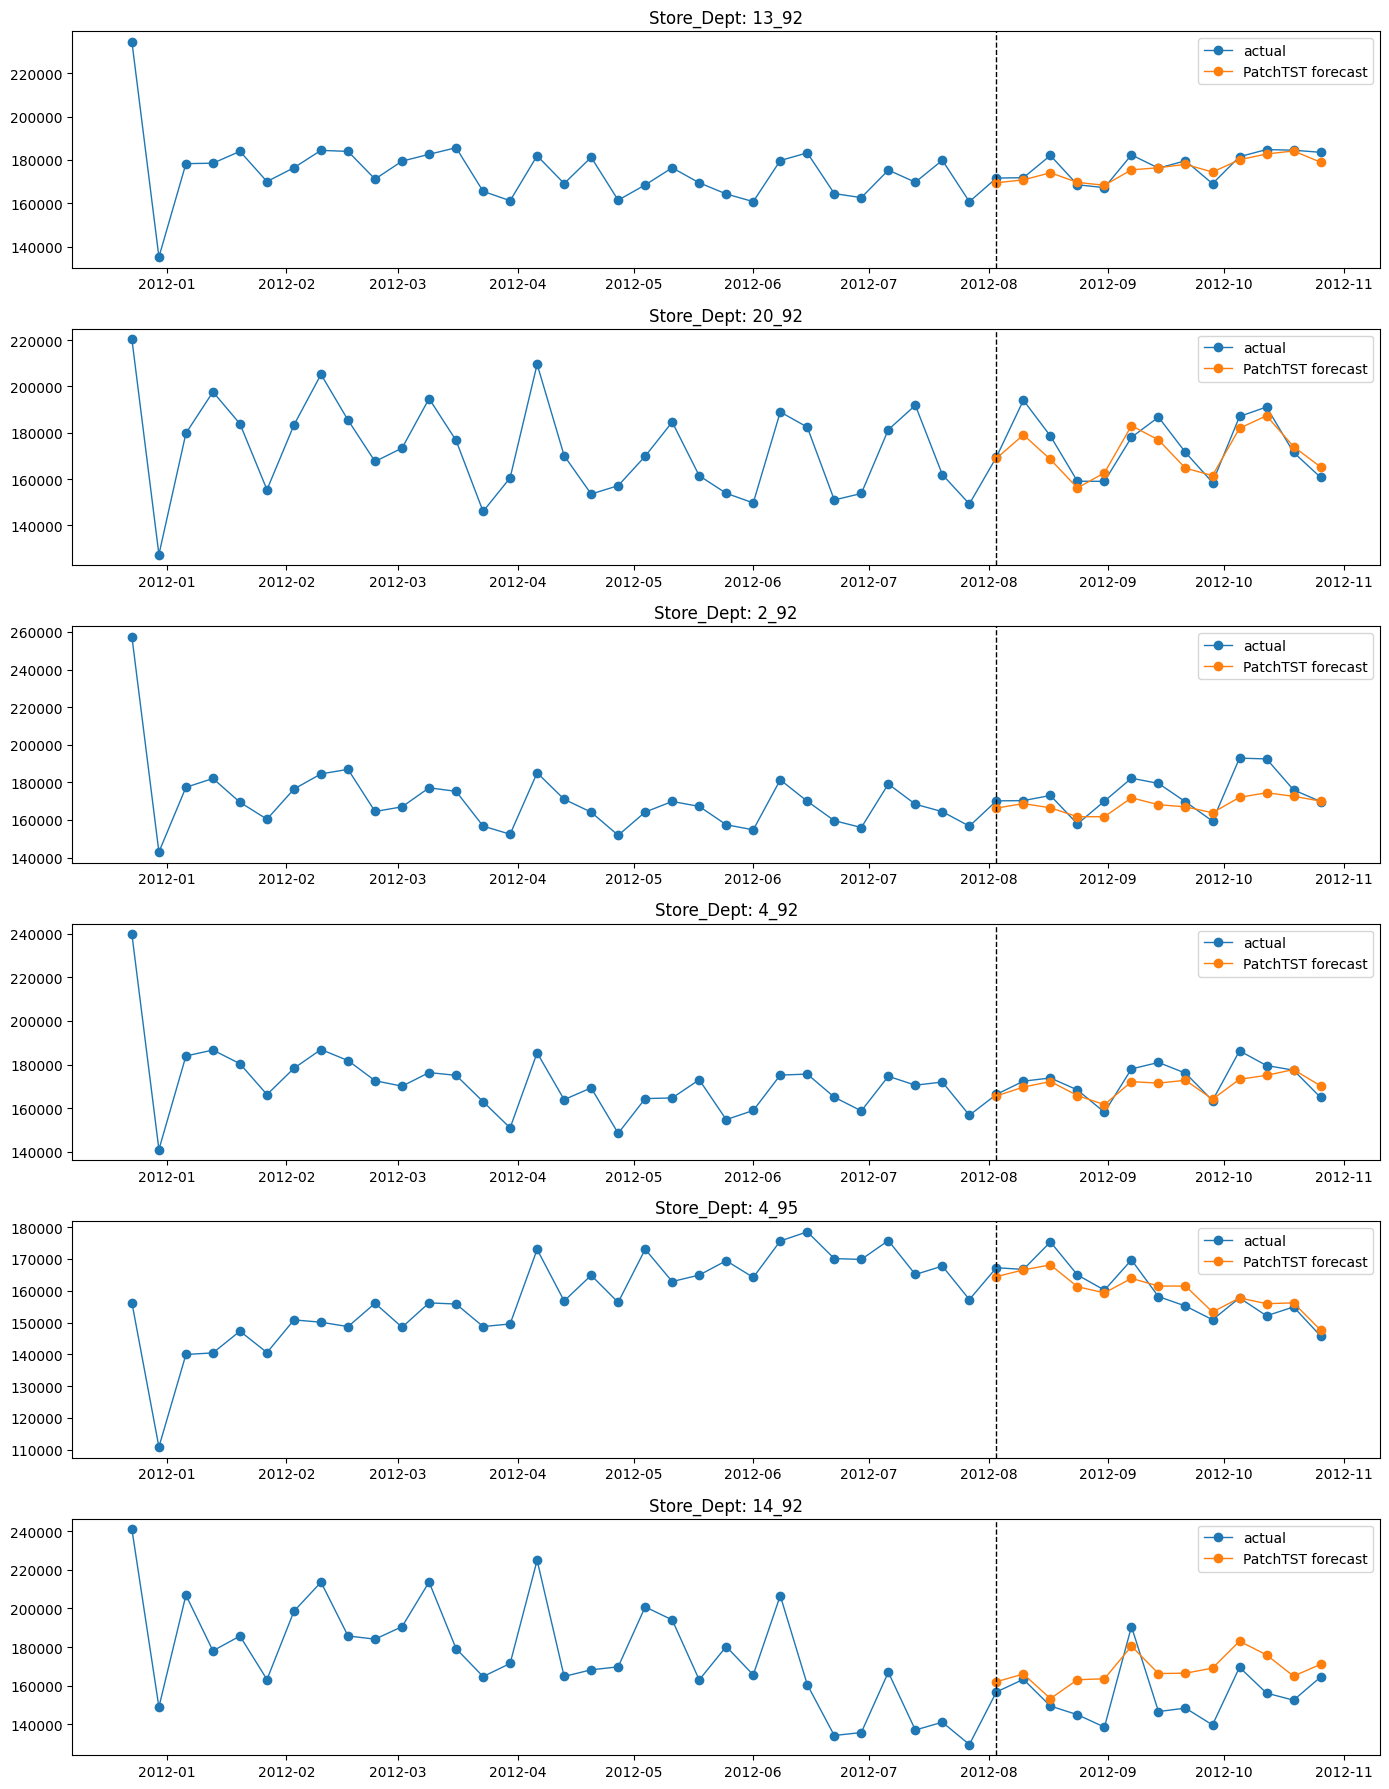

🏃 View run PatchTST_Validation_Visualization_Full at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/4/runs/8005ef1310cb4f7ab2b189dc171eb044
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/4


In [ ]:
plot_source = tuned_scored
plot_ids = plot_source.groupby("unique_id")["y"].sum().nlargest(6).index

fig, axes = plt.subplots(len(plot_ids), 1, figsize=(14, 3 * len(plot_ids)), sharex=False)

if len(plot_ids) == 1:
    axes = [axes]

for ax, uid in zip(axes, plot_ids):
    hist = nf_full[nf_full["unique_id"] == uid].tail(45)
    val = plot_source[plot_source["unique_id"] == uid]

    ax.plot(hist["ds"], hist["y"], label="actual", marker="o", linewidth=1)
    ax.plot(val["ds"], val["PatchTST"], label="PatchTST forecast", marker="o", linewidth=1)
    ax.axvline(valid_start, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"Store_Dept: {uid}")
    ax.legend()

plt.tight_layout()

plot_path = ARTIFACT_DIR / f"tuned_validation_plot_{run_suffix.lower()}.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

with mlflow.start_run(run_name=f"PatchTST_Validation_Visualization_{run_suffix}"):
    mlflow.log_param("source_run_id", patchtst_tuning_run_id)
    mlflow.log_artifact(str(plot_path), artifact_path="plots")

# Comparison

In [ ]:
runs = mlflow.search_runs(experiment_names=["PatchTST_Training"])

cols = [
    "tags.mlflow.runName",
    "metrics.validation_wmae",
    "params.run_type",
    "params.input_size",
    "params.patch_len",
    "params.stride",
    "params.hidden_size",
    "params.n_heads",
    "params.max_steps",
    "params.learning_rate",
    "params.quick_run",
]

available_cols = [col for col in cols if col in runs.columns]

comparison = (
    runs[available_cols]
    .dropna(subset=["metrics.validation_wmae"])
    .sort_values("metrics.validation_wmae")
)

comparison

,tags.mlflow.runName,metrics.validation_wmae,params.run_type,params.input_size,params.patch_len,params.stride,params.hidden_size,params.n_heads,params.max_steps,params.learning_rate,params.quick_run
2,PatchTST_Training_Baseline_Full,1165.824968,baseline,78,13,13,64,4,1000,0.0001,False
1,PatchTST_Tuning_Input104_Patch16_Stride8_Full,1259.774570,hyperparameter_tuning,104,16,8,128,8,1500,5e-05,False
6,PatchTST_Tuning_Input104_Patch16_Stride8_Quick,6055.724935,hyperparameter_tuning,104,16,8,128,8,75,5e-05,True
7,PatchTST_Training_Baseline_Quick,7078.087030,baseline,78,13,13,64,4,50,0.0001,True
